In [1]:
import os

import torch
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
model = ["resnet34", "vgg19", "mlp12"]
optimizer = ["fullbatch_gd", "sgd", "sgd_momentum", "adam", "adamw", "muon"]

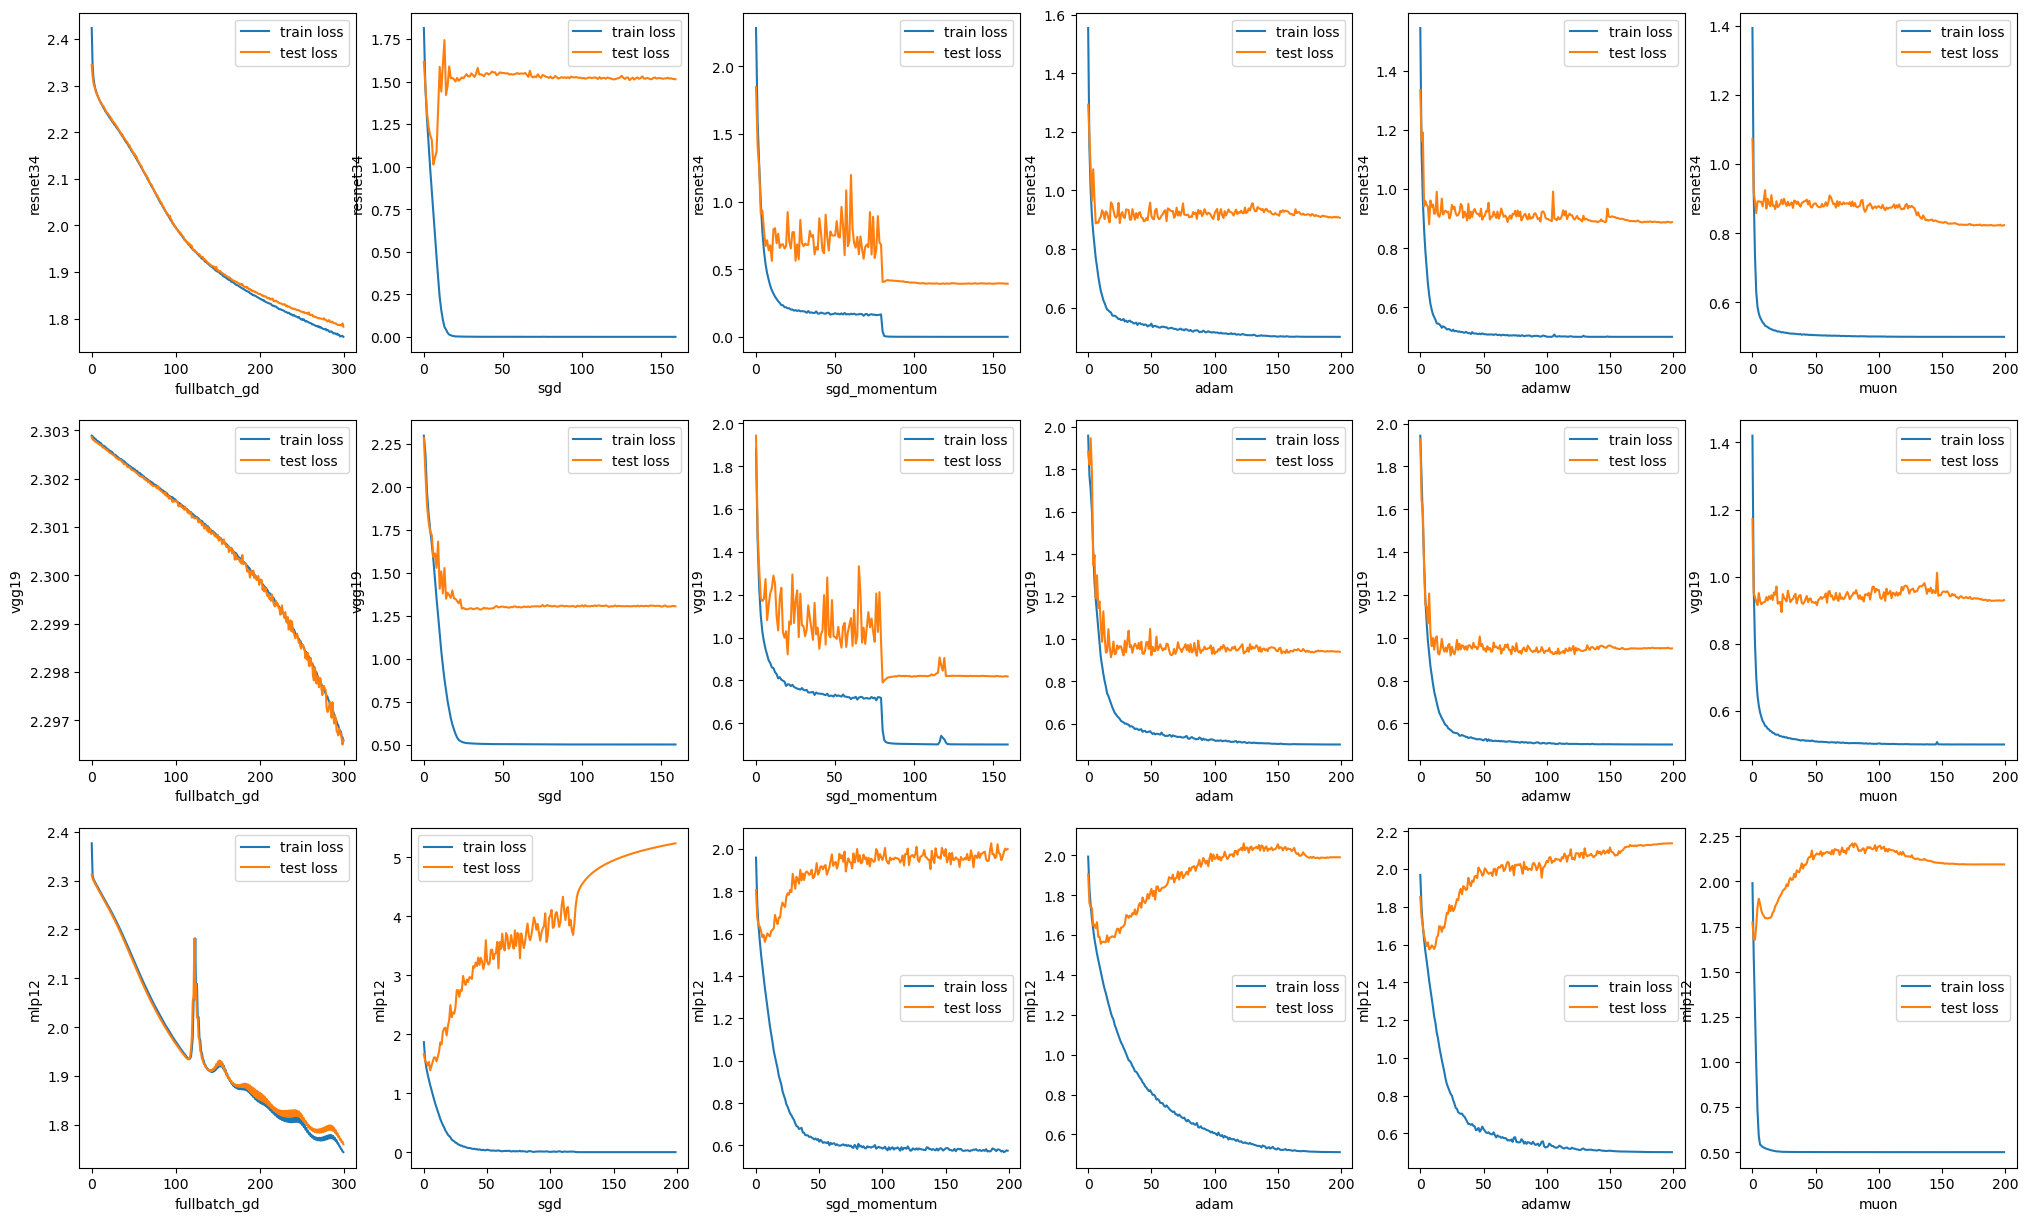

In [3]:
fig, axs = plt.subplots(3, 6, figsize=(25, 15))

for i, m in enumerate(model):
    for j, opt in enumerate(optimizer):
        model_path = f"results/{m}_cifar10_{opt}/checkpoints/"
        if not os.path.exists(model_path):
            continue

        checkpoints = os.listdir(model_path)
        checkpoints.sort(key=lambda x: int(x.split(".")[0][5:]))

        if len(checkpoints) == 0:
            continue

        checkpoint = torch.load(os.path.join(model_path, checkpoints[-1]), map_location="cpu")

        axs[i, j].plot(checkpoint["train_history"]['loss'], label="train loss")
        axs[i, j].plot(checkpoint["test_history"]['loss'], label="test loss")
        axs[i, j].set_xlabel(opt)
        axs[i, j].set_ylabel(m)
        axs[i, j].legend(title="")
plt.show()

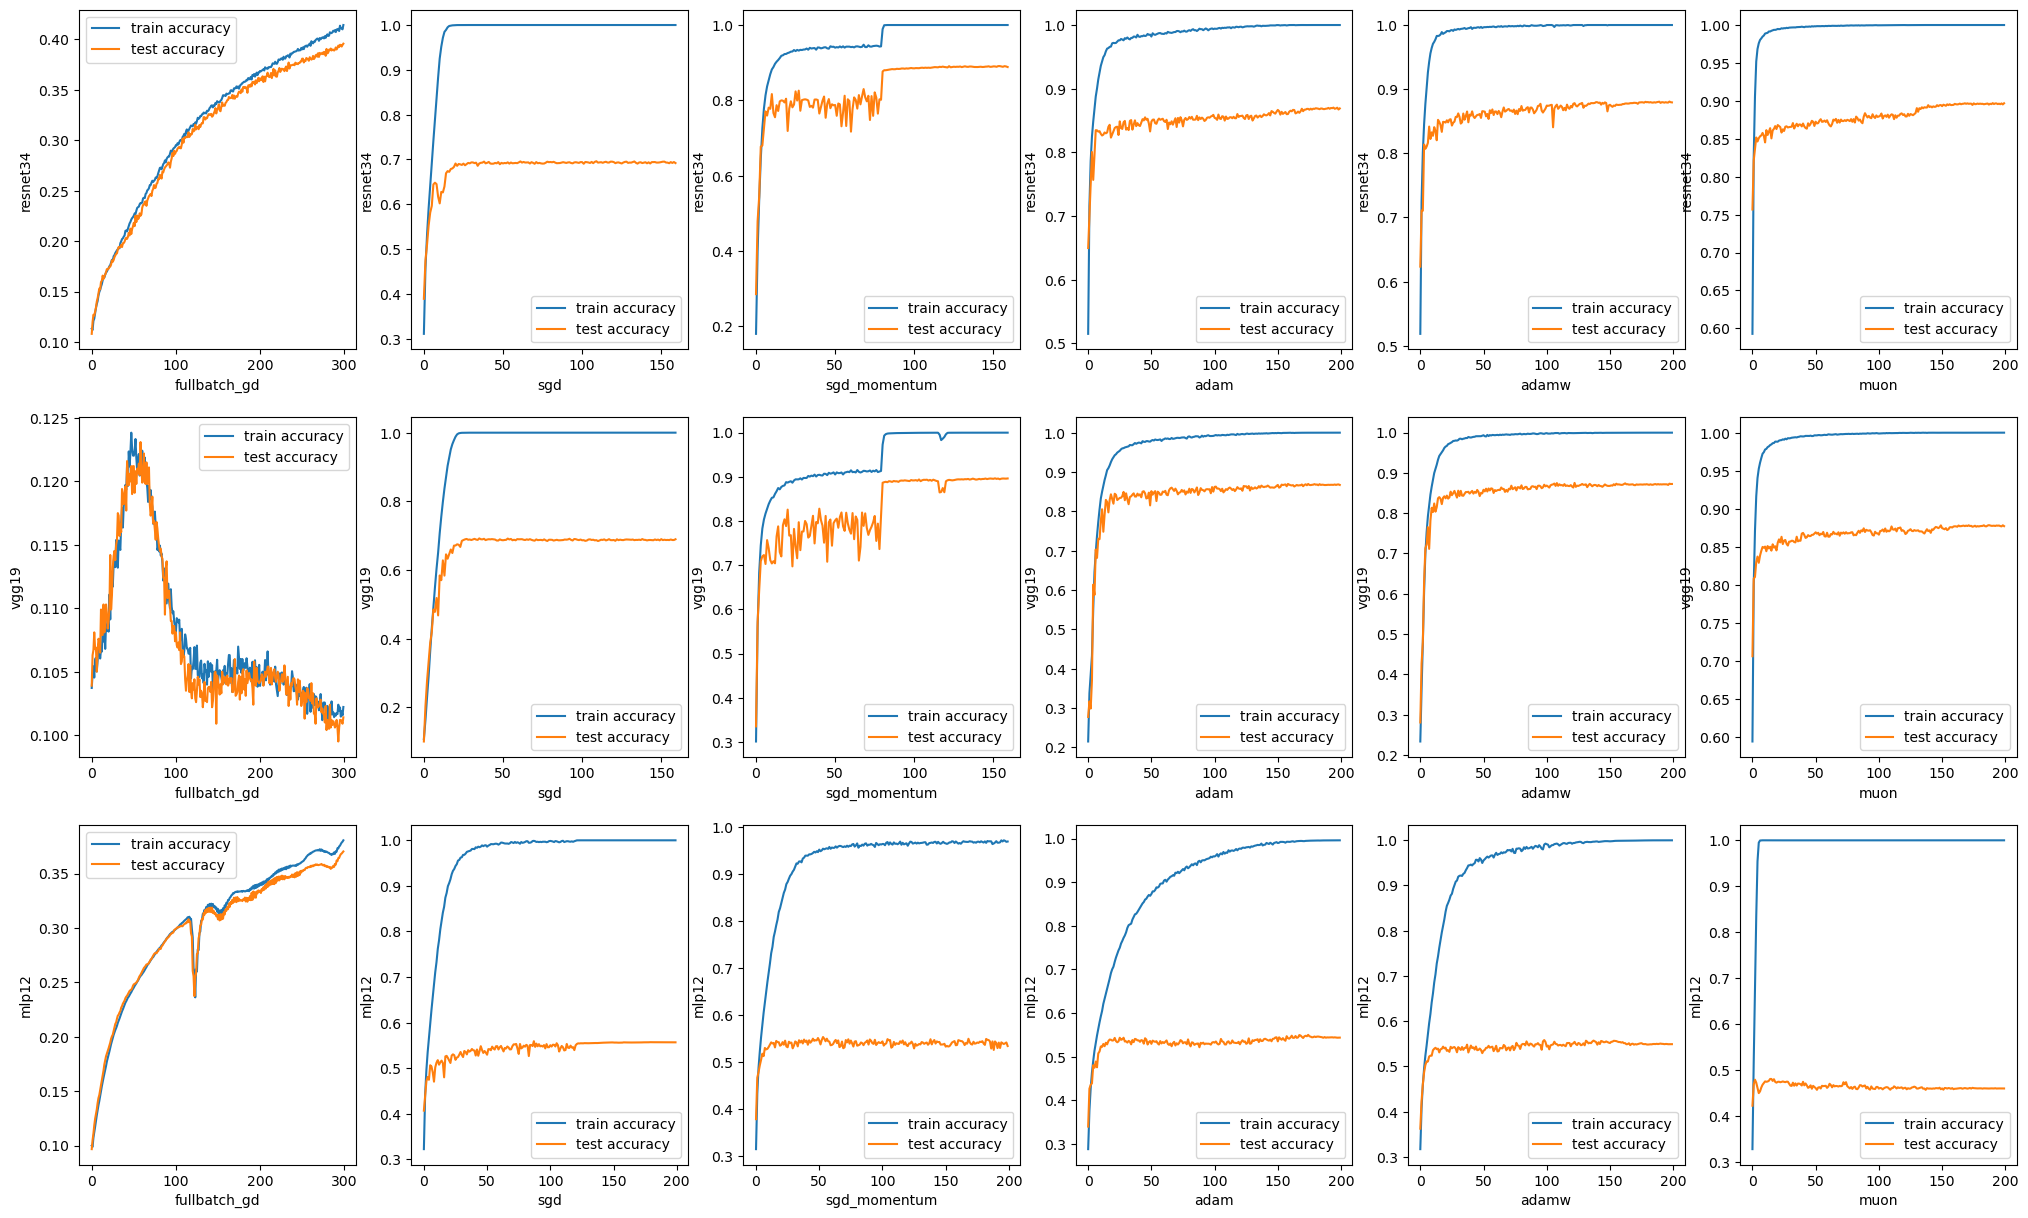

In [4]:
fig, axs = plt.subplots(3, 6, figsize=(25, 15))

for i, m in enumerate(model):
    for j, opt in enumerate(optimizer):
        model_path = f"results/{m}_cifar10_{opt}/checkpoints/"
        if not os.path.exists(model_path):
            continue

        checkpoints = os.listdir(model_path)
        checkpoints.sort(key=lambda x: int(x.split(".")[0][5:]))

        if len(checkpoints) == 0:
            continue

        checkpoint = torch.load(os.path.join(model_path, checkpoints[-1]), map_location="cpu")

        axs[i, j].plot(checkpoint["train_history"]['accuracy'], label="train accuracy")
        axs[i, j].plot(checkpoint["test_history"]['accuracy'], label="test accuracy")
        axs[i, j].set_xlabel(opt)
        axs[i, j].set_ylabel(m)
        axs[i, j].legend(title="")
plt.show()

Model: resnet34


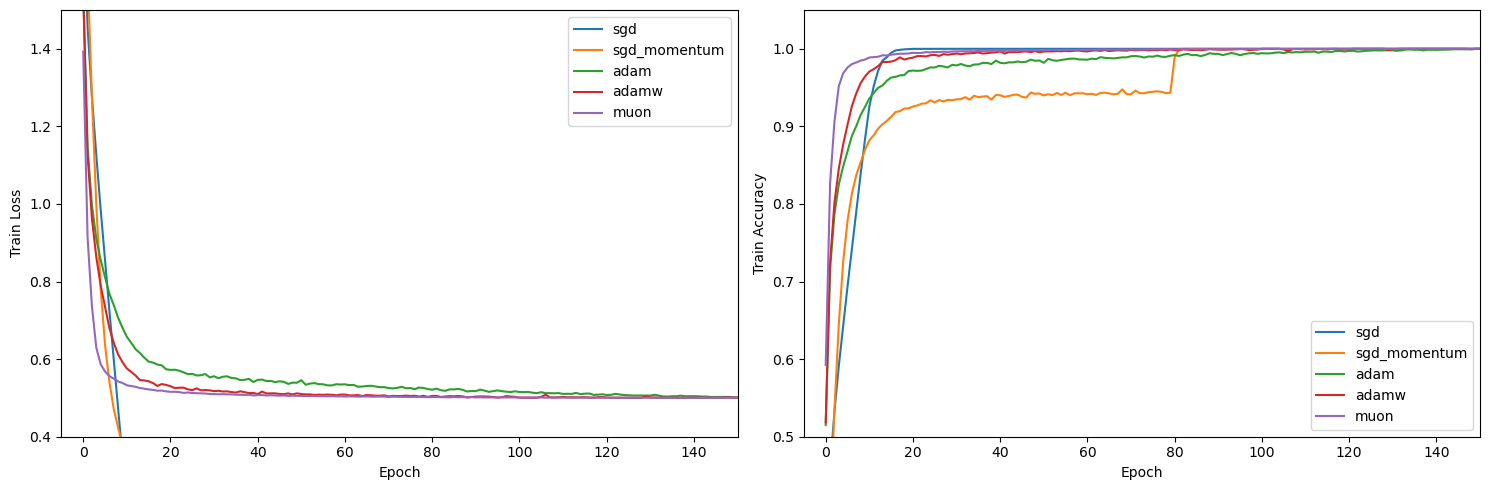

Model: vgg19


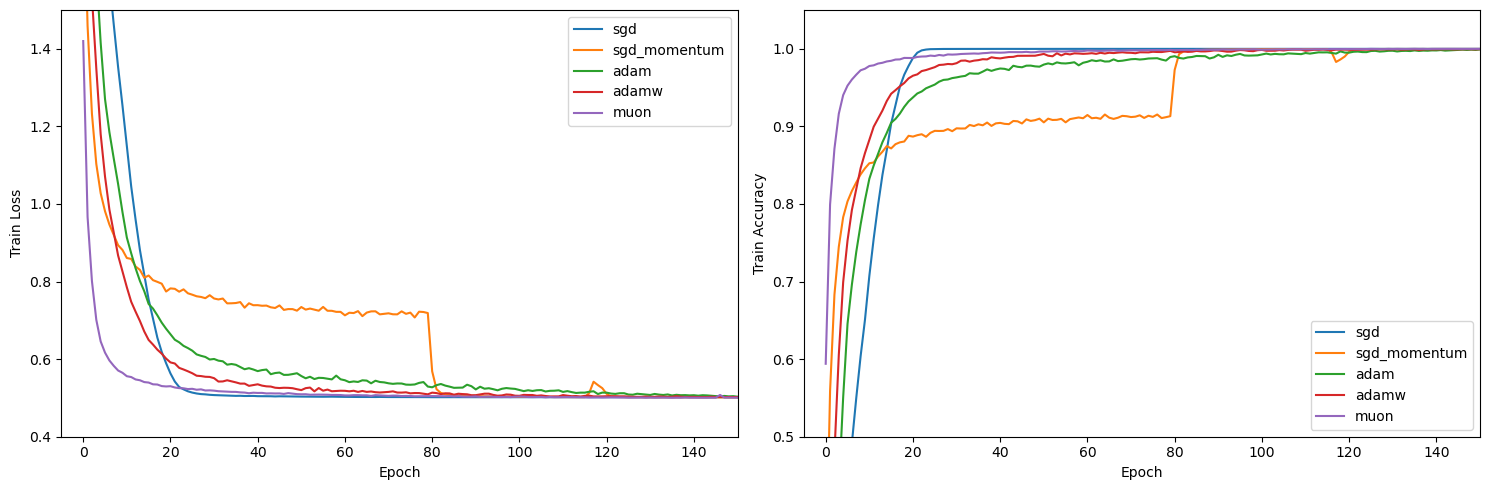

Model: mlp12


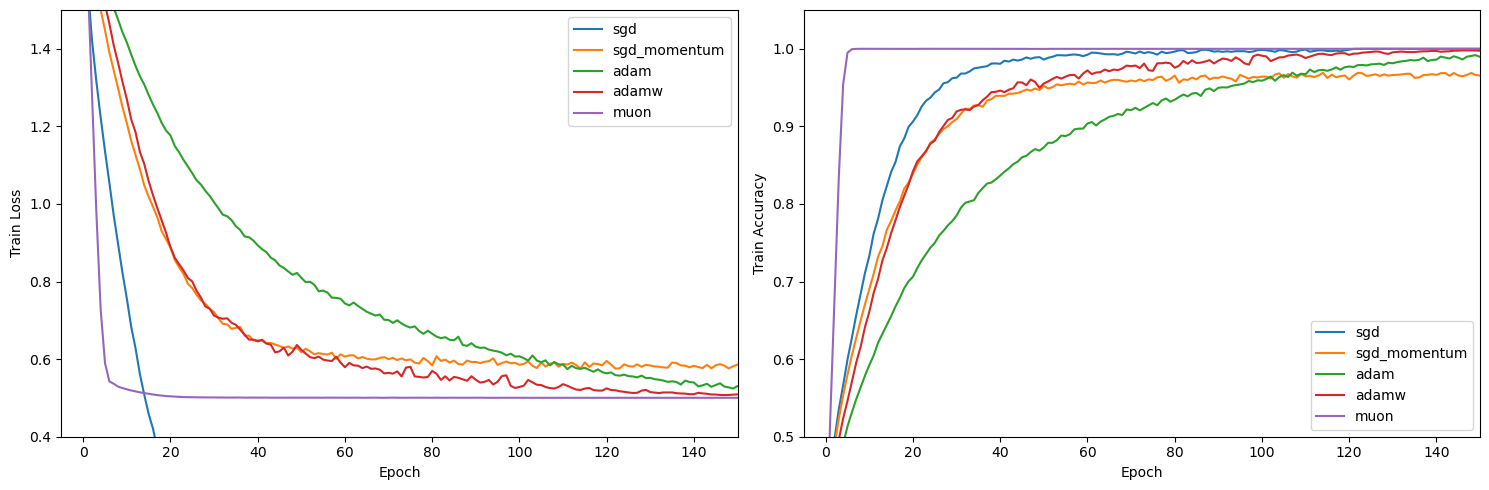

In [5]:
for i, m in enumerate(model):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    print(f"Model: {m}")
    for j, opt in enumerate(optimizer):
        if opt == "fullbatch_gd": continue
        model_path = f"results/{m}_cifar10_{opt}/checkpoints/"
        if not os.path.exists(model_path):
            continue

        checkpoints = os.listdir(model_path)
        checkpoints.sort(key=lambda x: int(x.split(".")[0][5:]))

        if len(checkpoints) == 0:
            continue

        checkpoint = torch.load(os.path.join(model_path, checkpoints[-1]), map_location="cpu")

        axs[1].plot(checkpoint["train_history"]['accuracy'], label=f"{opt}")
        axs[0].plot(checkpoint["train_history"]['loss'], label=f"{opt}")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Train Accuracy")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Train Loss")
    axs[1].legend(title="")
    axs[0].legend(title="")
    axs[1].set_ylim(0.5, 1.05)
    axs[1].set_xlim(-5, 150)
    axs[0].set_ylim(0.4, 1.5)
    axs[0].set_xlim(-5, 150)
    plt.tight_layout()
    plt.show()